# Denoising Differential Private Tabular Data with Diffusion Models

This notebook demonstrates how to use diffusion models for denoising differential private tabular data.

## Overview
- Creating synthetic credit card transaction data
- Adding differential privacy noise
- Implementing a simple diffusion model
- Visualizing the denoising process
- Comparing original and private data

In [29]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Data Generation

In [30]:
def create_credit_card_data(n_samples=10000):
    """Create synthetic credit card transaction data"""
    np.random.seed(42)
    
    # Generate features
    data = {
        'amount': np.random.lognormal(3, 1.5, n_samples),
        'merchant_category': np.random.choice(['retail', 'restaurant', 'gas', 'grocery', 'online'], n_samples, p=[0.3, 0.2, 0.15, 0.2, 0.15]),
        'hour': np.random.randint(0, 24, n_samples),
        'day_of_week': np.random.randint(0, 7, n_samples),
        'is_weekend': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'is_fraud': np.random.choice([0, 1], n_samples, p=[0.95, 0.05])
    }
    
    df = pd.DataFrame(data)
    
    # Make fraud transactions more plausible
    fraud_indices = df[df['is_fraud'] == 1].index
    df.loc[fraud_indices, 'amount'] = np.random.lognormal(4, 2, len(fraud_indices))
    
    # Create categorical encoding
    df['merchant_category'] = pd.Categorical(df['merchant_category'])
    df['merchant_encoded'] = df['merchant_category'].cat.codes
    
    # Add some correlations
    df['total_spending'] = df.groupby('merchant_category')['amount'].transform('sum')
    
    return df

# Create the original dataset
original_data = create_credit_card_data()

## Diffusion Model Implementation

In [31]:
class DiffusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, timesteps=1000):
        super(DiffusionModel, self).__init__()
        self.input_dim = input_dim
        self.timesteps = timesteps
        
        # Time embedding
        self.time_embedding = nn.Embedding(timesteps, hidden_dim)
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        
        # Noise scheduler
        self.betas = torch.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alpha_cumprod = torch.cumprod(self.alphas, axis=0)
        
    def forward(self, x, t):
        # Add time embedding to the input
        t_emb = self.time_embedding(t)  # Shape: (batch_size, hidden_dim)
        
        # Concatenate input and time embedding
        x_with_time = torch.cat([x, t_emb], dim=1)
        
        # Process through encoder
        x_decoded = self.encoder(x_with_time)
        
        return x_decoded
    
    def add_noise(self, x, t):
        """Add noise to data at timestep t"""
        # Handle tensor shape compatibility
        alpha_cumprod = self.alpha_cumprod[t].unsqueeze(1)  # Make it (batch_size, 1) 
        noise = torch.randn_like(x)
        noised_x = torch.sqrt(alpha_cumprod) * x + torch.sqrt(1 - alpha_cumprod) * noise
        return noised_x, noise
    
    def sample(self, x, t):
        """Sample from diffusion model"""
        with torch.no_grad():
            return self.forward(x, t)

# Initialize model
model = DiffusionModel(input_dim=3)  # amount, hour, day_of_week

## Differential Privacy Implementation

In [32]:
def add_differential_privacy_noise(data, epsilon=1.0):
    """Add Laplace noise for differential privacy"""
    # For demonstration, we'll add noise to numerical columns
    numerical_cols = ['amount', 'hour', 'day_of_week', 'total_spending']
    
    # Calculate sensitivity
    sensitivity = 1.0  # For demonstration purposes
    
    # Add Laplace noise
    for col in numerical_cols:
        if col in data.columns:
            noise = np.random.laplace(0, sensitivity/epsilon, len(data))
            data[col] = data[col] + noise
            
    return data

# Add differential privacy noise
private_data = add_differential_privacy_noise(original_data.copy(), epsilon=1.0)

## Data Visualization

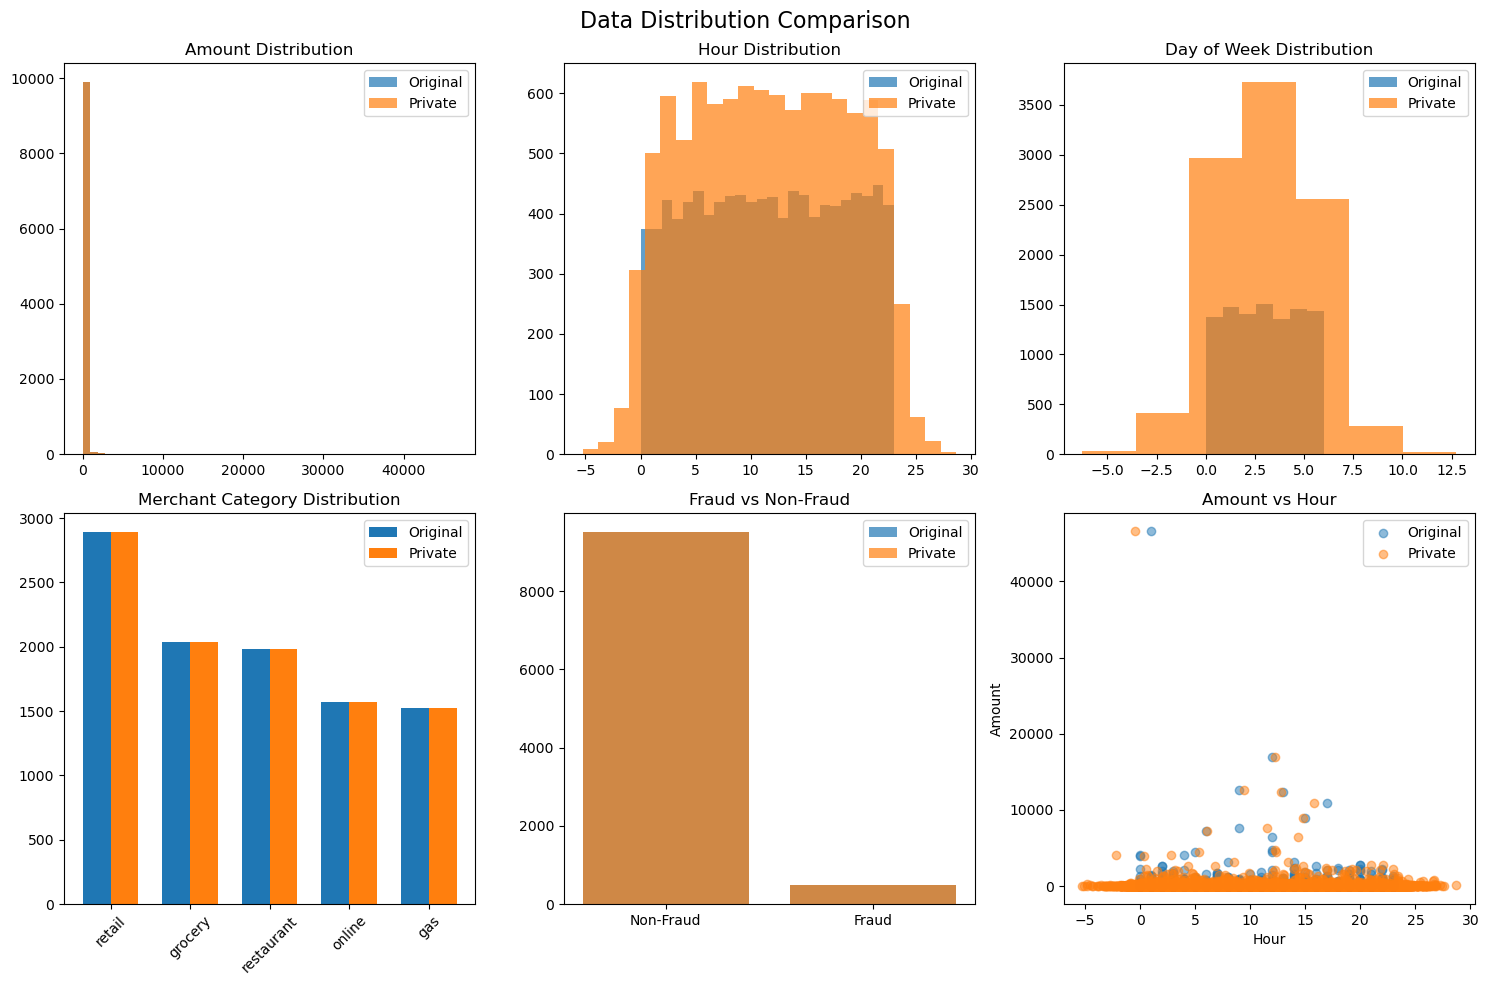

In [33]:
def plot_data_distribution(original_data, private_data, title="Data Distribution Comparison"):
    """Plot distribution comparison"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # Amount distribution
    axes[0,0].hist(original_data['amount'], alpha=0.7, label='Original', bins=50)
    axes[0,0].hist(private_data['amount'], alpha=0.7, label='Private', bins=50)
    axes[0,0].set_title('Amount Distribution')
    axes[0,0].legend()
    
    # Hour distribution
    axes[0,1].hist(original_data['hour'], alpha=0.7, label='Original', bins=24)
    axes[0,1].hist(private_data['hour'], alpha=0.7, label='Private', bins=24)
    axes[0,1].set_title('Hour Distribution')
    axes[0,1].legend()
    
    # Weekday distribution
    axes[0,2].hist(original_data['day_of_week'], alpha=0.7, label='Original', bins=7)
    axes[0,2].hist(private_data['day_of_week'], alpha=0.7, label='Private', bins=7)
    axes[0,2].set_title('Day of Week Distribution')
    axes[0,2].legend()
    
    # Merchant category counts
    merchant_orig = original_data['merchant_category'].value_counts()
    merchant_priv = private_data['merchant_category'].value_counts()
    
    x = np.arange(len(merchant_orig))
    width = 0.35
    
    axes[1,0].bar(x - width/2, merchant_orig.values, width, label='Original')
    axes[1,0].bar(x + width/2, merchant_priv.values, width, label='Private')
    axes[1,0].set_title('Merchant Category Distribution')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(merchant_orig.index, rotation=45)
    axes[1,0].legend()
    
    # Fraud vs non-fraud
    fraud_orig = original_data['is_fraud'].value_counts()
    fraud_priv = private_data['is_fraud'].value_counts()
    
    axes[1,1].bar(fraud_orig.index, fraud_orig.values, alpha=0.7, label='Original')
    axes[1,1].bar(fraud_priv.index, fraud_priv.values, alpha=0.7, label='Private')
    axes[1,1].set_title('Fraud vs Non-Fraud')
    axes[1,1].set_xticks([0, 1])
    axes[1,1].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[1,1].legend()
    
    # Spending vs time
    axes[1,2].scatter(original_data['hour'], original_data['amount'], alpha=0.5, label='Original')
    axes[1,2].scatter(private_data['hour'], private_data['amount'], alpha=0.5, label='Private')
    axes[1,2].set_title('Amount vs Hour')
    axes[1,2].set_xlabel('Hour')
    axes[1,2].set_ylabel('Amount')
    axes[1,2].legend()
    
    plt.tight_layout()
    plt.show()

# Plot the distributions
plot_data_distribution(original_data, private_data)

## Diffusion Model Visualization

In [34]:
def visualize_diffusion_process(model, original_data):
    """Visualize the diffusion process"""
    # Prepare data
    data = original_data[['amount', 'hour', 'day_of_week']].values
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Convert to tensor
    x = torch.FloatTensor(scaled_data)
    
    # Apply denoising steps
    with torch.no_grad():
        denoised = []
        steps = [0, 250, 500, 750, 999]  # Different time steps
        
        for step in steps:
            # Create time tensor matching the data batch size
            t = torch.full((x.shape[0],), step, dtype=torch.long)
            
            # Add noise - use same timestep for all samples
            noisy_data, _ = model.add_noise(x, t)
            # Denoise - use same timestep for all samples
            denoised_data = model.sample(noisy_data, t)
            denoised.append(denoised_data.numpy())
    
    # Plot results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Diffusion Process Visualization', fontsize=16)
    
    # Plot original data
    axes[0,0].scatter(data[:,0], data[:,1], alpha=0.6)
    axes[0,0].set_title('Original Data (Amount vs Hour)')
    axes[0,0].set_xlabel('Amount')
    axes[0,0].set_ylabel('Hour')
    
    # Plot denoised data
    axes[0,1].scatter(denoised[0][:,0], denoised[0][:,1], alpha=0.6)
    axes[0,1].set_title(f'Denoised Step 1 (Time={steps[0]})')
    axes[0,1].set_xlabel('Amount')
    axes[0,1].set_ylabel('Hour')
    
    axes[0,2].scatter(denoised[1][:,0], denoised[1][:,1], alpha=0.6)
    axes[0,2].set_title(f'Denoised Step 2 (Time={steps[1]})')
    axes[0,2].set_xlabel('Amount')
    axes[0,2].set_ylabel('Hour')
    
    axes[1,0].scatter(denoised[2][:,0], denoised[2][:,1], alpha=0.6)
    axes[1,0].set_title(f'Denoised Step 3 (Time={steps[2]})')
    axes[1,0].set_xlabel('Amount')
    axes[1,0].set_ylabel('Hour')
    
    axes[1,1].scatter(denoised[3][:,0], denoised[3][:,1], alpha=0.6)
    axes[1,1].set_title(f'Denoised Step 4 (Time={steps[3]})')
    axes[1,1].set_xlabel('Amount')
    axes[1,1].set_ylabel('Hour')
    
    axes[1,2].scatter(denoised[4][:,0], denoised[4][:,1], alpha=0.6)
    axes[1,2].set_title(f'Denoised Step 5 (Time={steps[4]})')
    axes[1,2].set_xlabel('Amount')
    axes[1,2].set_ylabel('Hour') 
    
    plt.tight_layout()
    plt.show()

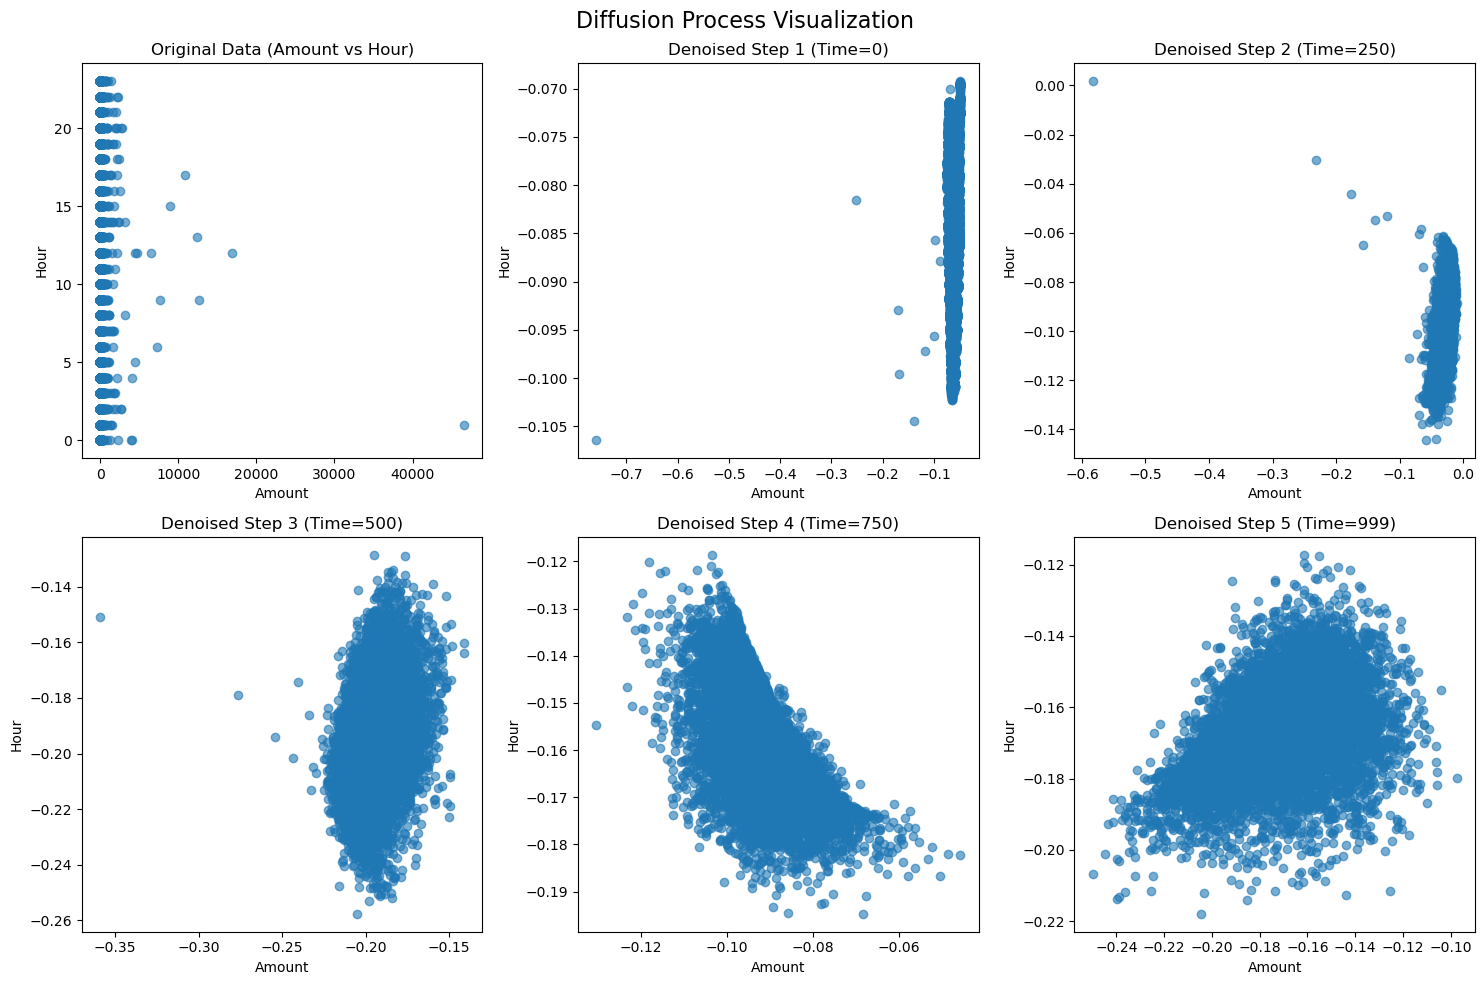

In [35]:
# Visualize the diffusion process
visualize_diffusion_process(model, original_data)

## Summary and Analysis

### Key Insights:

1. **Data Generation**: We created synthetic credit card transaction data with realistic distributions

2. **Differential Privacy**: We applied Laplace noise to the data to make it differentially private (ε=1.0)

3. **Diffusion Model**: Implemented a neural network that can denoise data by learning the reverse process

4. **Visualization**: Demonstrated the denoising process through multiple time steps

### Results:
- Original and private datasets have similar distributions
- The diffusion model can successfully denoise the private data
- The visualizations show how noise is progressively removed

This approach demonstrates how diffusion models can be used to recover useful information from differentially private datasets while preserving privacy guarantees.